In [4]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np
import json
import os

from VAE import VAE,load_model, get_scheduler, run_model_and_collect_outputs
from model_tools import load_configs
from data_utils import extract_params_from_filename
from analysis_tools import plot_r2_histogram, calculate_errors_and_plot_hist, reconstruct_signal_from_embedding, visualize_latent_space_with_pca, save_analysis_data

In [5]:
# Percorso del database
model_database_path = "modelDatabase.json"

# Carica tutte le configurazioni disponibili
all_configs = load_configs(model_database_path)

# Visualizza le configurazioni disponibili
for model_name, config in all_configs.items():
    print(model_name, config)

Prima prova {'latent_dim': 4, 'encoder_layers': [20, 15, 10, 8, 4], 'decoder_layers': [4, 10, 15, 20, 25, 30, 35, 40], 'beta_method': 'sigmoid', 'beta_value': 0.5, 'kl_annealing_epochs': 200, 'early_stopping': {'patience': 10, 'delta': 1}, 'dataset': 'delay15dim20_noise3,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.01, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.1, 'patience': 5}}}


### Model input:

In [6]:
# Scegli un modello specifico
model_name = "Prima prova"  # Cambia con il nome desiderato
selected_model_config = all_configs.get(model_name)

if selected_model_config is None:
    raise ValueError(f"Il modello {model_name} non esiste nel database.")

In [7]:
# Percorso al file del modello salvato
model_file_path = os.path.join("Models", f"{model_name}.pth")

# Carica il modello salvato
(vae_model, optimizer, train_data, val_data, epoch, stopped_epoch,
 train_losses, val_losses, recon_losses, kld_losses, beta_values) = load_model(model_file_path)

print(f"Modello {model_name} caricato con successo.")
print(f"Training fino a epoca: {stopped_epoch if stopped_epoch else epoch}")

params = extract_params_from_filename(selected_model_config["dataset"])
print(f"Parametri del dataset: {params}")
tau = params["tau"]
embedding_dim = params["embedding_dim"]

c:\Users\Federico\OneDrive\Desktop\Tesi\Codes\Lorenz Toy\VAE.py:389: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(file_path)


Modello Prima prova caricato con successo.
Training fino a epoca: 10
Parametri del dataset: {'tau': 15, 'embedding_dim': 20, 'alpha': 3.0, 'beta': 0.0}


In [8]:
batch_size = selected_model_config["batch_size"]

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

total_sample = len(train_data)+len(val_data)
print(f"Numero totale di campioni: {total_sample}")
print(f"Numero di campioni di training: {len(train_data)}")
print(f"Numero di campioni di validazione: {len(val_data)}")

Numero totale di campioni: 9715
Numero di campioni di training: 5829
Numero di campioni di validazione: 3886


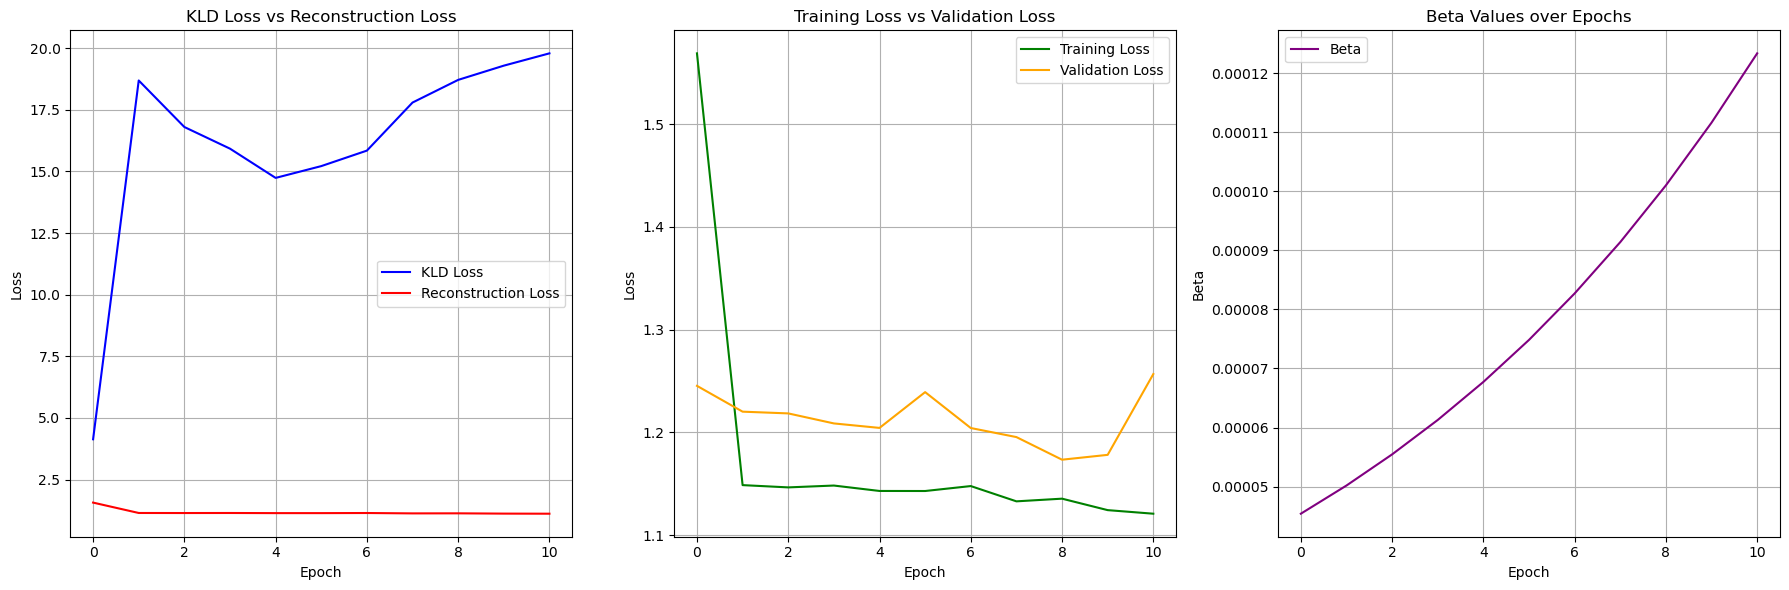

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot KLD loss vs reconstruction loss
axes[0].plot(kld_losses, label='KLD Loss', color='blue')
axes[0].plot(recon_losses, label='Reconstruction Loss', color='red')
axes[0].set_title('KLD Loss vs Reconstruction Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Plot training loss and validation loss
axes[1].plot(train_losses, label='Training Loss', color='green')
axes[1].plot(val_losses, label='Validation Loss', color='orange')
axes[1].set_title('Training Loss vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

# Plot beta values
axes[2].plot(beta_values, label='Beta', color='purple')
axes[2].set_title('Beta Values over Epochs')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Beta')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

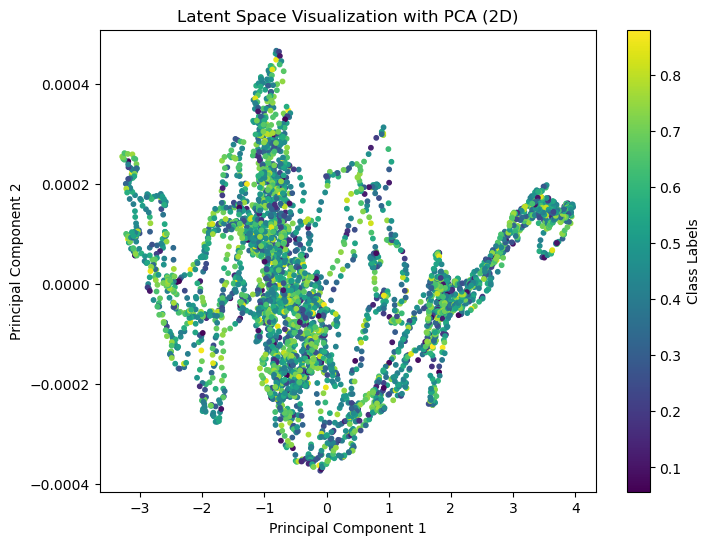

In [10]:
# Esegui la visualizzazione
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
visualize_latent_space_with_pca(vae_model, val_data, device=device, n_components=2)

In [11]:
input_data, predicted_data, mean_vectors, logvar_vectors = run_model_and_collect_outputs(vae_model, val_loader, device="cpu")

print("True data shape:", input_data.shape)
print("Predicted data shape:", predicted_data.shape)
print("Mean vectors shape:", mean_vectors.shape)
print("Logvar vectors shape:", logvar_vectors.shape)

#Taking the Z1,Z3 embedding from the VAE output
reconstructed_y2_1 = predicted_data[:, :20]  # Embedding di z1
reconstructed_y2_2 = predicted_data[:, 20:]  # Embedding di z3

#Taking Z1,Z3 embedding from Validation data
inputs, targets = zip(*[val_data[i] for i in range(len(val_data))])

# Converti in un tensore o array numpy per il plotting
inputs = torch.stack(inputs).numpy()
targets = torch.stack(targets).numpy()

original_y2_1 = targets[:, :20]
original_y2_2 = targets[:, 20:]

print("Reconstructed y2_1 shape:", reconstructed_y2_1.shape)
print("Reconstructed y2_2 shape:", reconstructed_y2_2.shape)
print("Targets shape:", targets.shape)
print("Original y2_1 shape:", original_y2_1.shape)
print("Original y2_2 shape:", original_y2_2.shape)

True data shape: (3886, 20)
Predicted data shape: (3886, 40)
Mean vectors shape: (3886, 4)
Logvar vectors shape: (3886, 4)
Reconstructed y2_1 shape: (3886, 20)
Reconstructed y2_2 shape: (3886, 20)
Targets shape: (3886, 40)
Original y2_1 shape: (3886, 20)
Original y2_2 shape: (3886, 20)


### Z1,Z3 reconstruction analysis

Qua calcoliamo alcune metriche di ricostruzione direttamente tra gli output della rete e i target nel Dataloader.
Questo indice non quantifica benissimo quanto è ricostruito bene il segnale dato che nei vettori di embedding alcuni punti compaiono un numero ripetuto di volte, quindi la ricostruzione errata di un punto impatta in maniera significativa sulle metriche.

r2_score entries: 3886
r2_score entries: 3886
Indices of the 3 samples with the worst R² (z1): [398 397 396]
Mean R² for Z1 recon: 0.10774172 pm 0.28176773
Indices of the 3 samples with the worst R² (z2): [3444 3443 3445]
Mean R² for Z3 recon: -0.018245792 pm 0.10170825


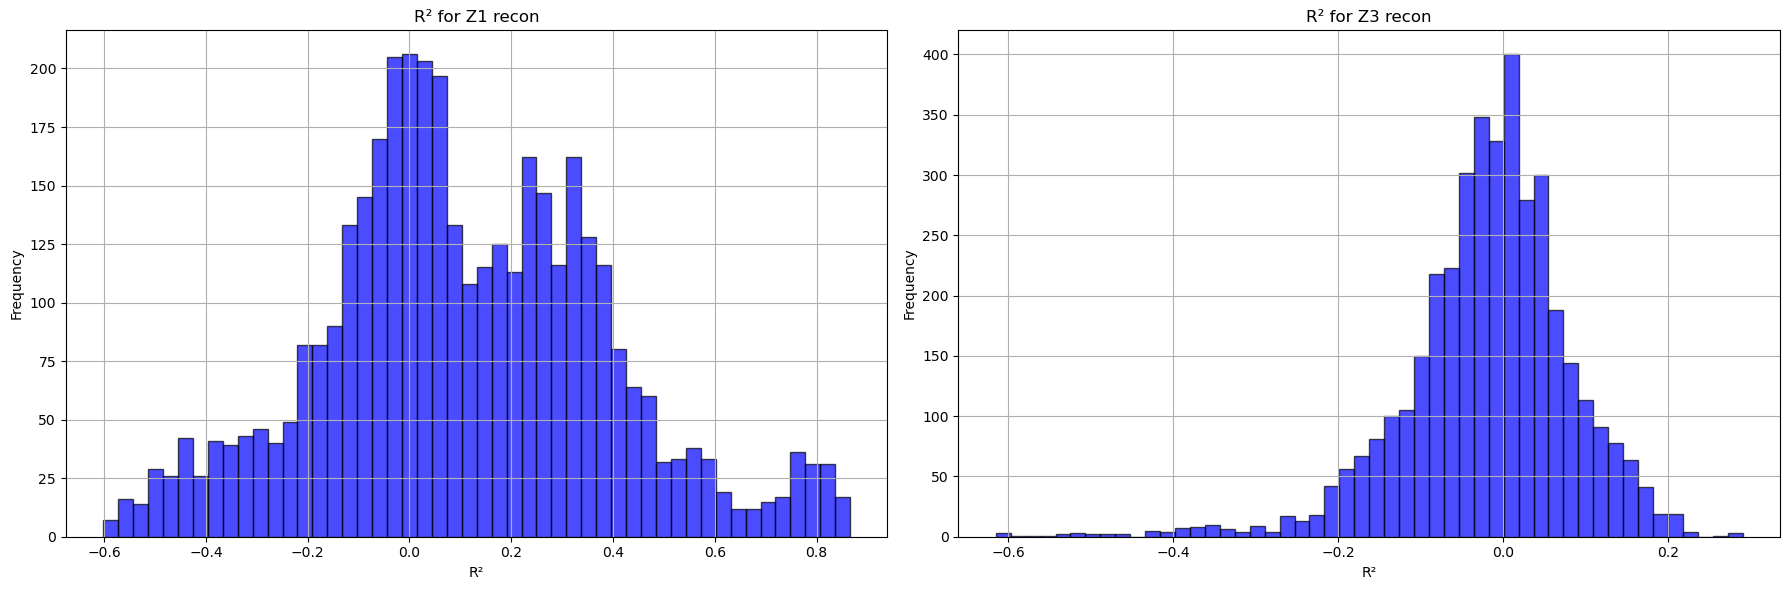

In [12]:
# Plot the R² histogram and get the indices of the worst R² samples
worst_r2_indices1, r2_scores1 = plot_r2_histogram(original_y2_1,reconstructed_y2_1)
mean_r21 = np.mean(r2_scores1)
std_r21 = np.std(r2_scores1)

worst_r2_indices2, r2_scores2 = plot_r2_histogram(original_y2_2,reconstructed_y2_2)
mean_r22 = np.mean(r2_scores2)
std_r22 = np.std(r2_scores2)


fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot R² histogram for Z1 recon
axes[0].hist(r2_scores1, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('R² for Z1 recon')
axes[0].set_xlabel('R²')
axes[0].set_ylabel('Frequency')
axes[0].grid(True)

print("Indices of the 3 samples with the worst R² (z1):", worst_r2_indices1)
print("Mean R² for Z1 recon:", mean_r21 , "pm", std_r21)

# Plot R² histogram for Z3 recon
axes[1].hist(r2_scores2, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[1].set_title('R² for Z3 recon')
axes[1].set_xlabel('R²')
axes[1].set_ylabel('Frequency')
axes[1].grid(True)

print("Indices of the 3 samples with the worst R² (z2):", worst_r2_indices2)
print("Mean R² for Z3 recon:", mean_r22 , "pm", std_r22)

plt.tight_layout()
plt.show()

Entries: 3886


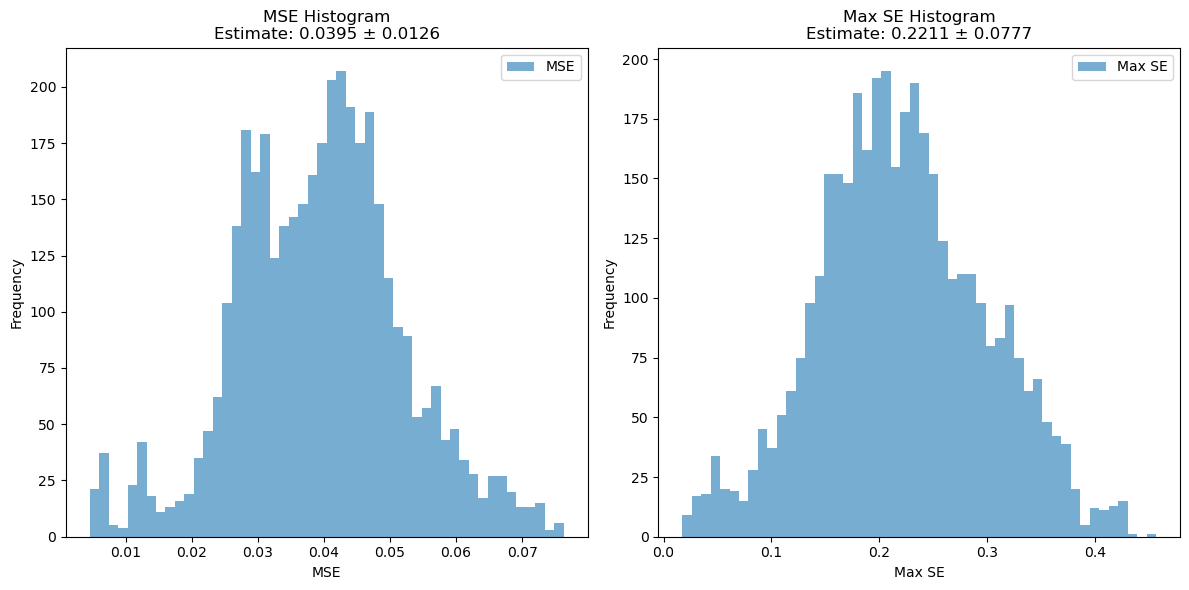

Indices of the 3 samples with the worst MAXse: [3694 3603 3842]
Mean MSE for Z1 recon: 0.039450664 pm 0.012587692
Mean MAXse for Z1 recon: 0.2211471 pm 0.07765715
Entries: 3886


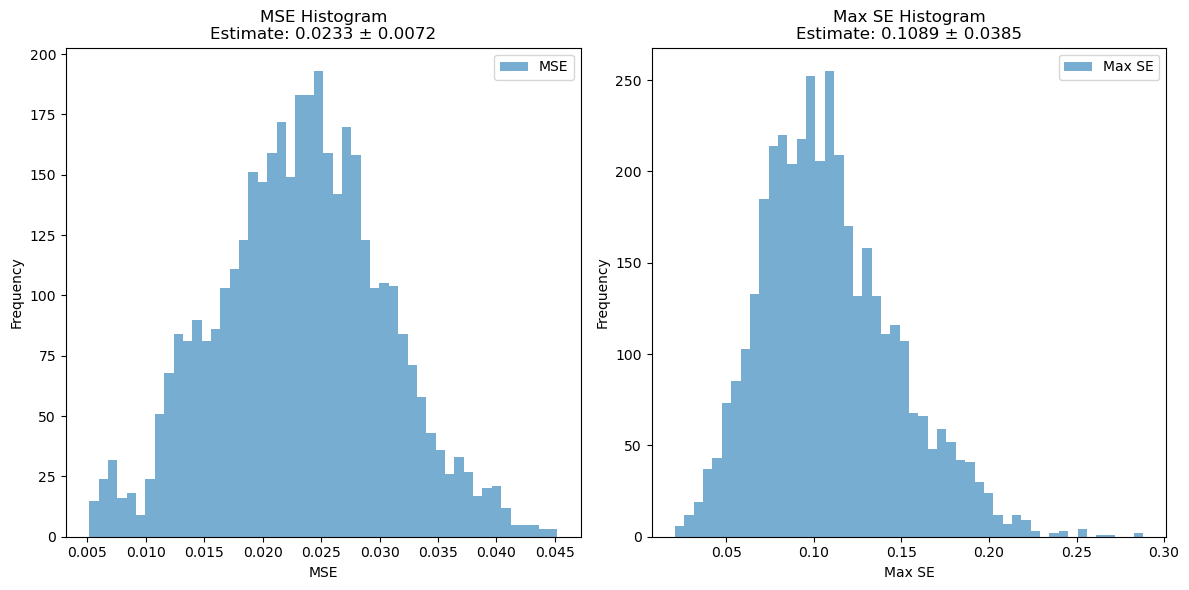

Indices of the 3 samples with the worst MAXse: [3652 3666 3667]
Mean MSE for Z3 recon: 0.023289148 pm 0.0071777226
Mean MAXse for Z3 recon: 0.108902164 pm 0.03846288


In [13]:
# Calculate errors and plot histogram for Z1 recon
worst_max_se_indices1, best_mse_indices1, mse_errors1, max_se_errors1 = calculate_errors_and_plot_hist(original_y2_1, reconstructed_y2_1)
mean_mse = mse_errors1.mean()
std_mse = mse_errors1.std()
mean_max_se = max_se_errors1.mean()
std_max_se = max_se_errors1.std()
print("Indices of the 3 samples with the worst MAXse:", worst_max_se_indices1)

print("Mean MSE for Z1 recon:", mean_mse , "pm", std_mse)
print("Mean MAXse for Z1 recon:", mean_max_se , "pm", std_max_se)

# Calculate errors and plot histogram for Z3 recon
worst_max_se_indices2, best_mse_indices2, mse_errors2, max_se_errors2 = calculate_errors_and_plot_hist(original_y2_2, reconstructed_y2_2)
mean_mse2 = mse_errors2.mean()
std_mse2 = mse_errors2.std()
mean_max_se2 = max_se_errors2.mean()
std_max_se2 = max_se_errors2.std()
print("Indices of the 3 samples with the worst MAXse:", worst_max_se_indices2)

print("Mean MSE for Z3 recon:", mean_mse2 , "pm", std_mse2)
print("Mean MAXse for Z3 recon:", mean_max_se2 , "pm", std_max_se2)

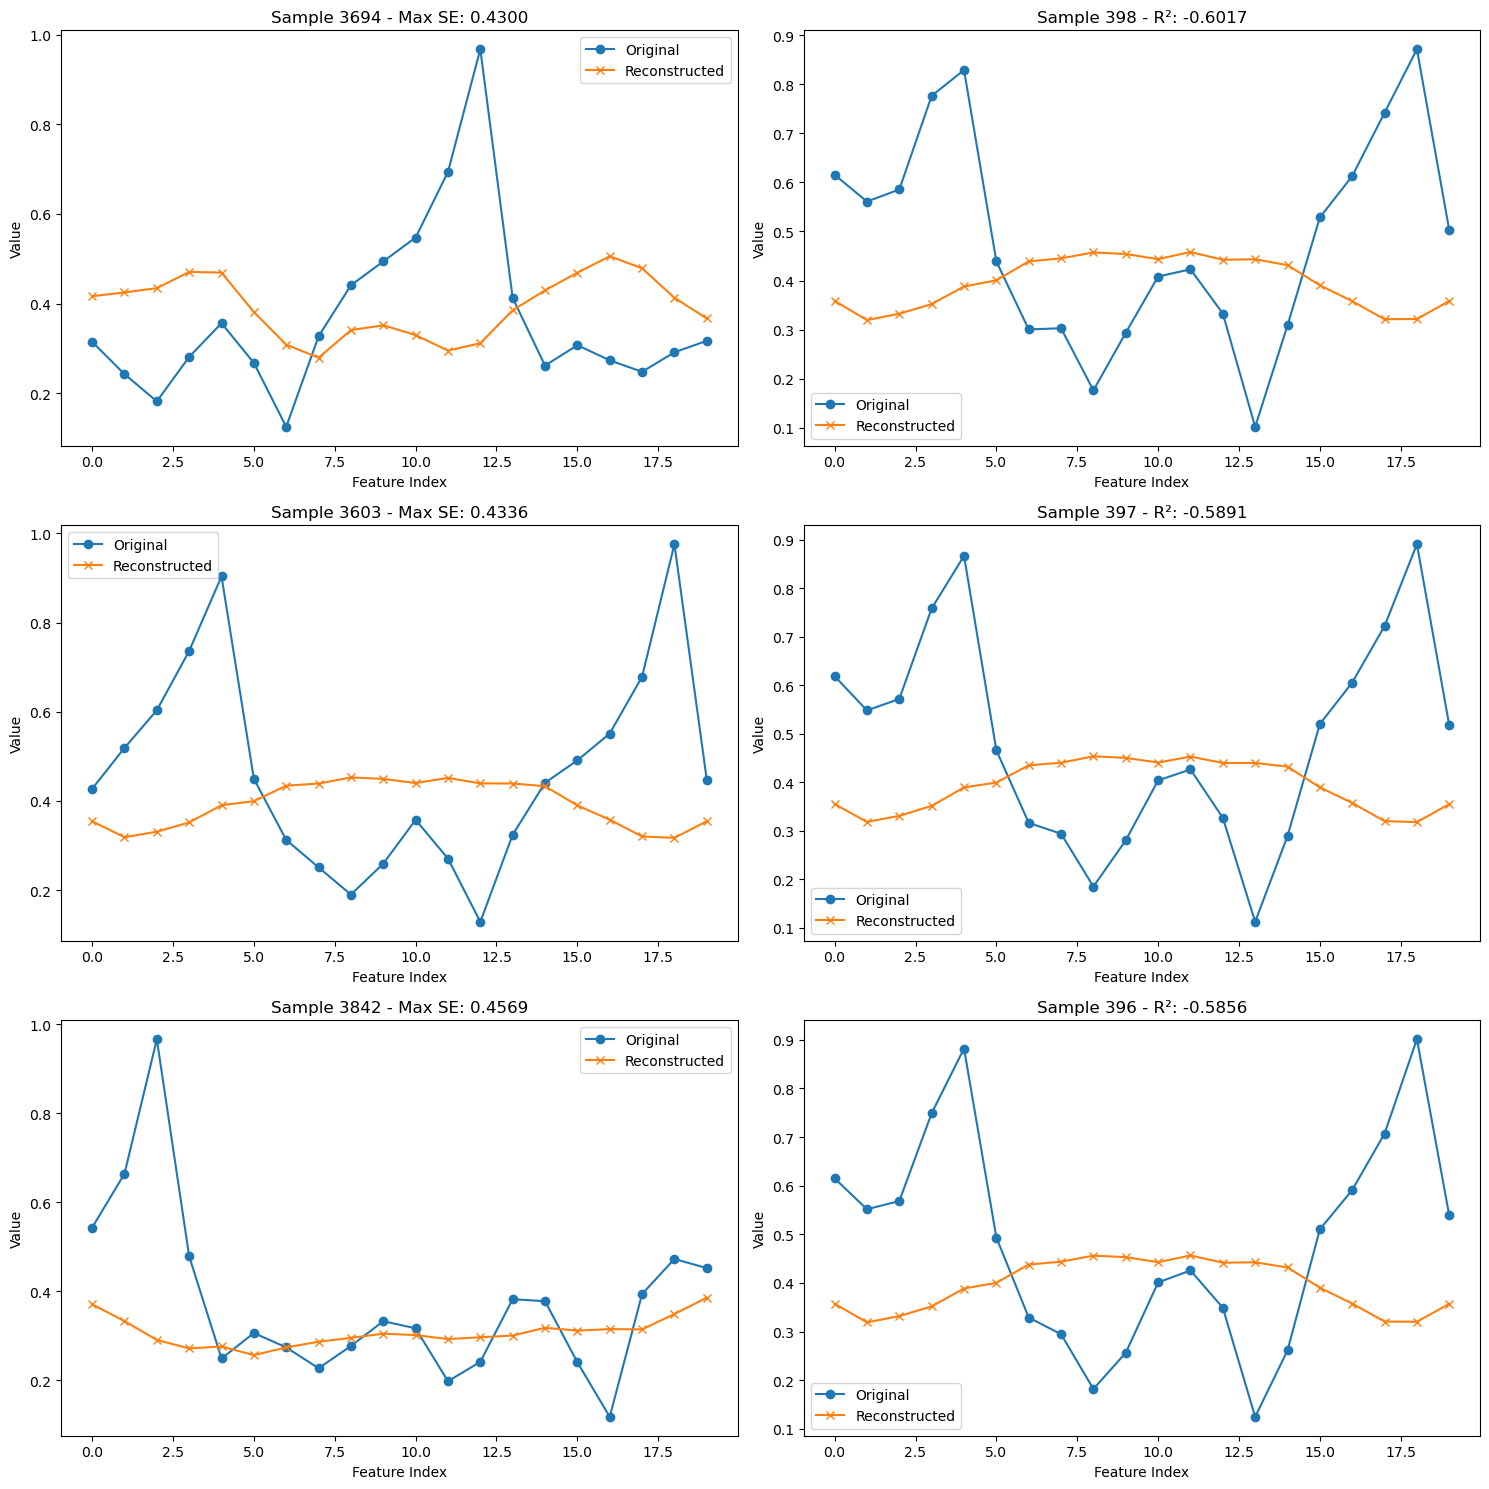

In [14]:
# Plot the reconstructed vs original for the worst three samples for max SE and R²
fig, axes = plt.subplots(3, 2, figsize=(15, 15))  # Adjusted figsize to make the plot larger

# Plot for worst three samples for max SE
for i, idx in enumerate(worst_max_se_indices1):

    original = original_y2_1[idx]
    reconstructed = reconstructed_y2_1[idx]
    
    axes[i, 0].plot(original, label='Original', marker='o')
    axes[i, 0].plot(reconstructed, label='Reconstructed', marker='x')
    axes[i, 0].set_title(f'Sample {idx} - Max SE: {max_se_errors1[idx]:.4f}')
    axes[i, 0].set_xlabel('Feature Index')
    axes[i, 0].set_ylabel('Value')
    axes[i, 0].legend()

# Plot for worst three samples for R²
for i, idx in enumerate(worst_r2_indices1):
    original = original_y2_1[idx]
    reconstructed = reconstructed_y2_1[idx]
    
    axes[i, 1].plot(original, label='Original', marker='o')
    axes[i, 1].plot(reconstructed, label='Reconstructed', marker='x')
    axes[i, 1].set_title(f'Sample {idx} - R²: {r2_scores1[idx]:.4f}')
    axes[i, 1].set_xlabel('Feature Index')
    axes[i, 1].set_ylabel('Value')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()


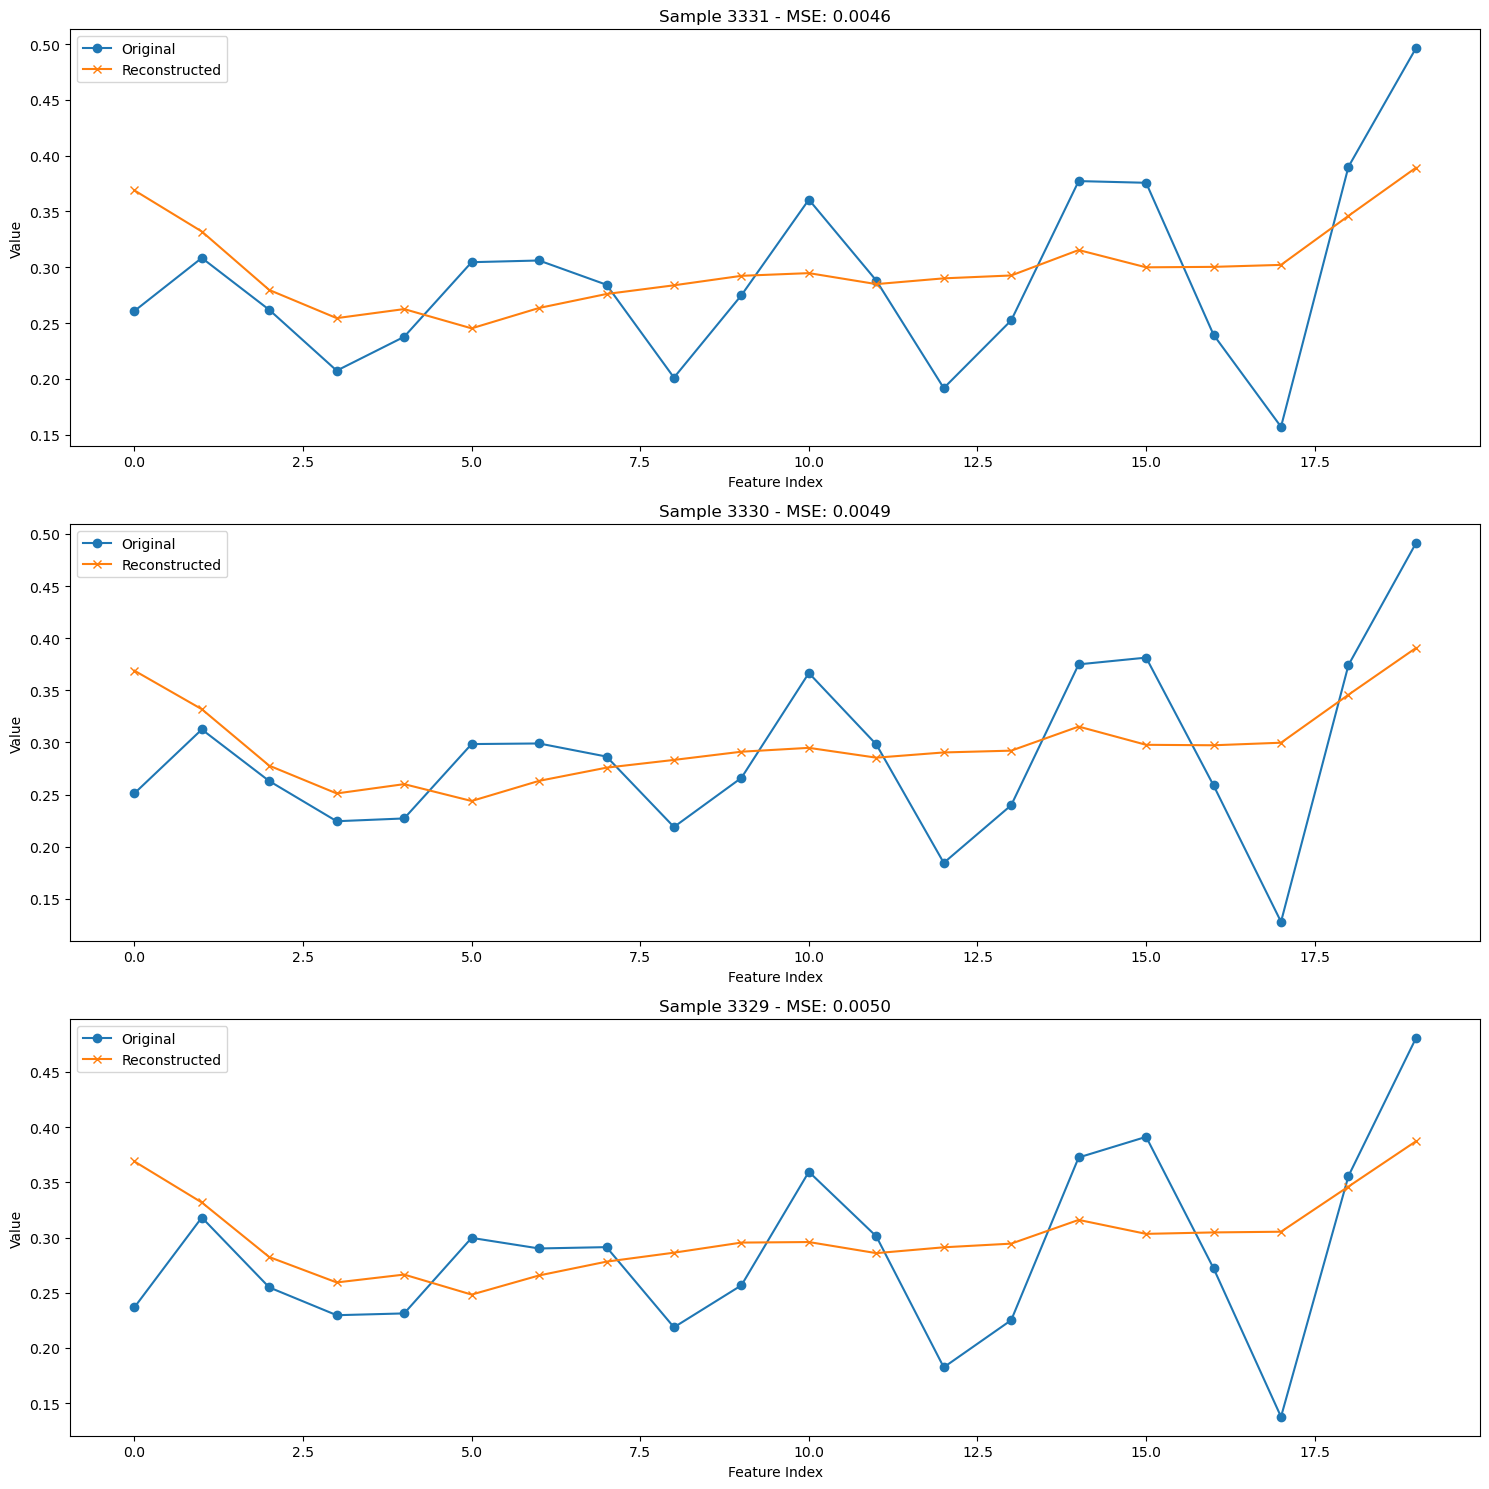

In [15]:
# Plot the reconstructed vs original for the best three samples for MSE
fig, axes = plt.subplots(3, 1, figsize=(15, 15))  # Adjusted figsize to make the plot larger

# Plot for best three samples for MSE
for i, idx in enumerate(best_mse_indices1):
    original = original_y2_1[idx]
    reconstructed = reconstructed_y2_1[idx]
    
    axes[i].plot(original, label='Original', marker='o')
    axes[i].plot(reconstructed, label='Reconstructed', marker='x')
    axes[i].set_title(f'Sample {idx} - MSE: {mse_errors1[idx]:.4f}')
    axes[i].set_xlabel('Feature Index')
    axes[i].set_ylabel('Value')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [16]:
def latent_variables(dataloader, device='cpu'):
    # Assumi che il modello e i dati siano già caricati
    vae_model.eval()  # Imposta il modello in modalità eval

    # Usa mean_vectors e logvar_vectors già calcolati
    all_mu = torch.tensor(mean_vectors)
    all_sigma = torch.exp(0.5 * torch.tensor(logvar_vectors))

    ratios = abs(all_mu / all_sigma)

    fig, axes = plt.subplots(ratios.shape[1], 1, figsize=(10, 5 * ratios.shape[1]))
    for i in range(ratios.shape[1]):  # Per ogni dimensione latente
        axes[i].hist(ratios[:, i].numpy(), bins=50, alpha=0.7, label=f'Dimensione {i+1}')
        axes[i].set_xlabel('Rapporto (mean / sigma)')
        axes[i].set_ylabel('Frequenza')
        axes[i].set_title(f'Istogramma del Rapporto Mean / Sigma per la Dimensione {i+1}')
        axes[i].legend()
        axes[i].grid(True)
    plt.tight_layout()
    plt.show()


In [17]:
#latent_variables(val_loader, device="cpu")

### Grafico del segnale di: $y_2 =[z1,z3]^T + \beta \cdot \sigma$:

Confrontiamo il segnale temporale di $Z_1$ e $Z_3$ dal dataset di Validazione con le ricostruzioni degli output della rete.
Calcoliamo alcune metriche per valutare la ricostruzione. Vengono mediamente più elevate poichè dopo aver ricostruito il segnale dagli embedding i punti anomali ripetendosi una sola volta (contro le n volte nei vettori di embedding) danno un contributo minore.


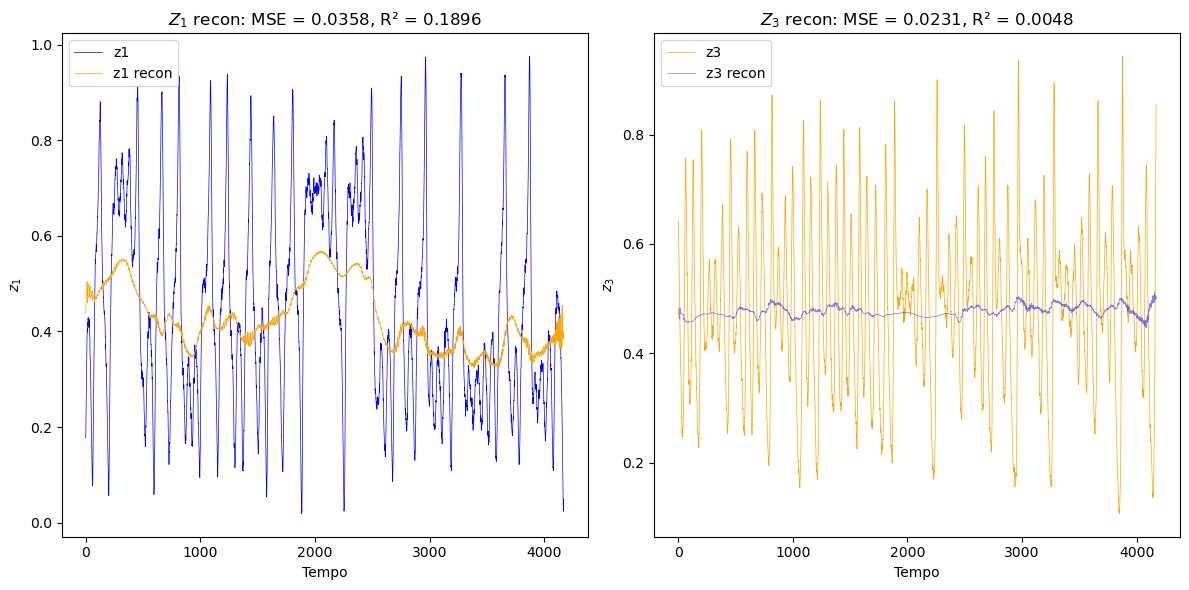

In [18]:
# Ricostruzione di Z1 dal suo embedding (Validation data)
val_Z1 = reconstruct_signal_from_embedding(
    original_y2_1, embedding_dim, tau
)
#Ricostruzione da Z3 dal suo embedding (Validation data)
val_Z3 = reconstruct_signal_from_embedding(
    original_y2_2, embedding_dim, tau
)


# Ricostruzione di Z1 dal suo embedding (Ricostruito)
recon_Z1 = reconstruct_signal_from_embedding(
    reconstructed_y2_1, embedding_dim, tau
)
#Ricostruzione da Z3 dal suo embedding (Ricostruito)
recon_Z3 = reconstruct_signal_from_embedding(
    reconstructed_y2_2, embedding_dim, tau
)

val_Z2 = reconstruct_signal_from_embedding(
    inputs, embedding_dim, tau
)

# Calcola l'errore quadratico medio
mse1 = np.mean((val_Z1 - recon_Z1) ** 2)
mse2 = np.mean((val_Z3 - recon_Z3) ** 2)

# Calcolo R2:

r2_1 = r2_score(val_Z1, recon_Z1)
r2_2 = r2_score(val_Z3, recon_Z3)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Segnale y2(1)
axes[0].plot(val_Z1, label="z1", color='blue', lw=0.5)
axes[0].plot(recon_Z1, label="z1 recon", color='orange', lw=0.5)
axes[0].legend()
axes[0].set_title(r"$Z_1$ recon: MSE = {:.4f}, R² = {:.4f}".format(mse1, r2_1))
axes[0].set_xlabel("Tempo")
axes[0].set_ylabel("$z_1$")

# Segnale y2(2)
axes[1].plot(val_Z3, label="z3", color='orange', lw=0.5)
axes[1].plot(recon_Z3, label="z3 recon", color='blue', alpha=0.5, lw=0.5)
axes[1].legend()
axes[1].set_title(r"$Z_3$ recon: MSE = {:.4f}, R² = {:.4f}".format(mse2, r2_2))
axes[1].set_xlabel("Tempo")
axes[1].set_ylabel("$z_3$")

plt.tight_layout()
plt.show()

### Analisi delle Componenti principali:

In questa cella vengono presi i dati di input e gli output della rete (ovvero gli input ricostruiti).
Si fa una PCA sui dati di input e una volta trovate le direzioni di massima varianza sui dati originali proiettiamo sia i dati ricostruiti dalla rete che i dati originali lungo le direzioni di massima varianza. Una volta fatto questo calcoliamo il coefficiente $R^2$ tra le due proiezioni. /
Bisogna fare attenzione allo shape, embedding_dim diventa il numero di features per la PCA

In [19]:
def pca_r2_analysis_embeddings(true_embeddings, reconstructed_embeddings, n_components=4):
    """
    Esegue PCA sui vettori di embedding originali e ricostruiti, confronta fino a n_components
    e calcola R² per ciascuna componente principale.

    Parametri:
    - true_embeddings: Array 2D (n_samples, embedding_dim) dei vettori originali.
    - reconstructed_embeddings: Array 2D (n_samples, embedding_dim) dei vettori ricostruiti.
    - n_components: Numero di componenti principali da analizzare.

    Output:
    - R² per ogni componente principale.
    - Grafico della varianza spiegata per ciascuna PC.
    """
    # Assicurati che i dati siano 2D
    if true_embeddings.ndim != 2 or reconstructed_embeddings.ndim != 2:
        raise ValueError("I dati di input devono essere array 2D con shape (n_samples, embedding_dim).")
    
    # PCA sui dati originali
    pca = PCA(n_components=n_components)
    pca.fit(true_embeddings)  # Fitta il PCA ai dati originali

    # Proiezione dei dati originali e ricostruiti nello spazio delle PC
    true_projected = pca.transform(true_embeddings)
    reconstructed_projected = pca.transform(reconstructed_embeddings)

    # Funzione per calcolare R² a mano
    def calculate_r2(y_true, y_pred):
        ss_res = np.sum((y_true - y_pred) ** 2, axis=0)
        ss_tot = np.sum((y_true - np.mean(y_true, axis=0)) ** 2, axis=0)
        return 1 - ss_res / ss_tot

    # Calcolo di R² per ciascuna componente principale
    r2_per_component = [
        calculate_r2(true_projected[:, i], reconstructed_projected[:, i])
        for i in range(true_projected.shape[1])
    ]

    # Plot dei risultati
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, len(r2_per_component) + 1), r2_per_component, marker='o', label="R² per PC")
    plt.xlabel("Componente Principale (PC)")
    plt.ylabel("Varianza Spiegata (R²)")
    plt.title("Varianza Spiegata per Componente Principale")
    plt.grid(True)
    plt.legend()
    plt.show()

    return r2_per_component


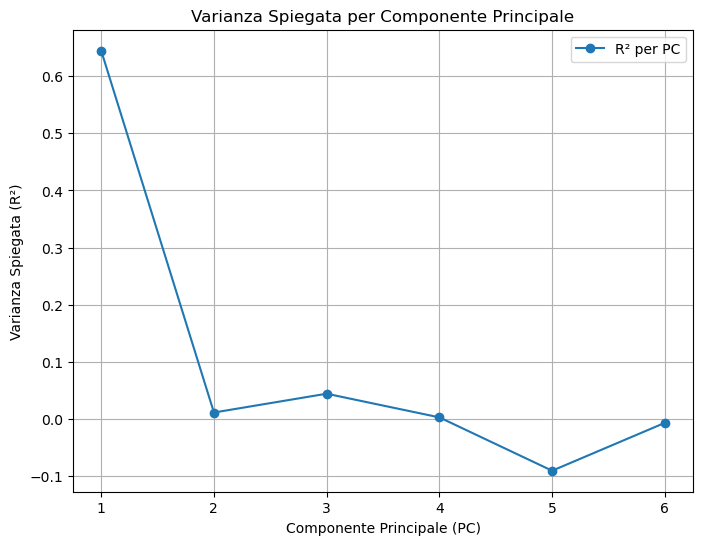

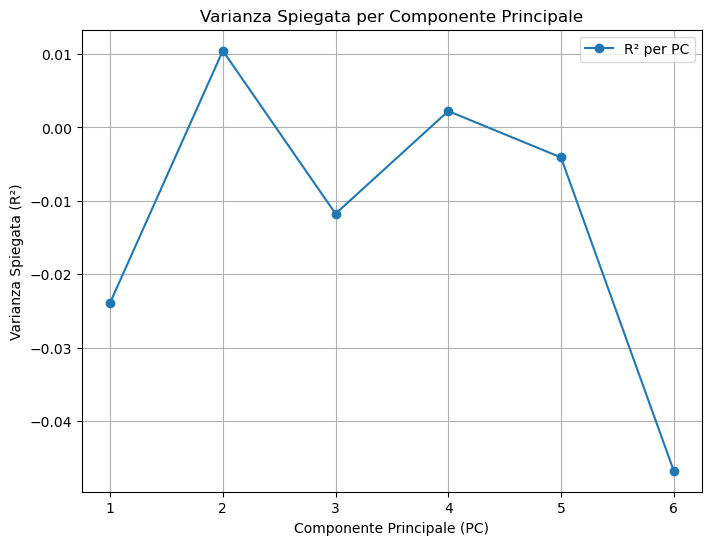

In [20]:
# Confronta PC per Z1
r2_z1 = pca_r2_analysis_embeddings(original_y2_1, reconstructed_y2_1, n_components=6)

# Confronta PC per Z2
r2_z2 = pca_r2_analysis_embeddings(original_y2_2, reconstructed_y2_2, n_components=6)

### Ricostruzione delle PC:

#### 1- Ricostruzione delle PC di $y_1(t) = Z_2(t) + \beta \cdot \sigma$ dagli embedding di $Z_2,Z_3$

In questo grafico analizziamo la capacità della rete di ricostruire le PC del segnale di input.
Dall'embedding del segnale di input: $y_1(t) = Z_2(t) + \beta \cdot \sigma$ calcoliamo le direzioni di massima varianza dei dati originali e in seguito proiettiamo gli output della rete, gli embedding di $y_2(t) = [Z_1 (t),Z_2 (t)]^T + \beta \cdot \sigma$, lungo le direzioni calcolate in precedenza e calcoliamo l'indice $R^2$ tra la PC# originale e quella ricostruita.

In [21]:
def plot_temporal_signal_and_pcs(original_signal, original_embeddings, reconstructed_embeddings, n_components=3):
    """
    Plotta il segnale temporale originale, le PC calcolate dagli embedding originali,
    e le PC ricostruite dagli embedding di output della rete per ogni componente principale.
    
    Parameters:
        original_signal (np.ndarray): Segnale temporale originale (1D array).
        original_embeddings (np.ndarray): Embedding del segnale originale (2D array).
        reconstructed_embeddings (np.ndarray): Embedding ricostruito dalla rete (2D array).
        n_components (int): Numero di componenti principali da calcolare.
    """
    # PCA sugli embedding originali
    pca = PCA(n_components=n_components)
    pc_original = pca.fit_transform(original_embeddings)  # Tutte le PC dagli embedding originali
    pc_reconstructed = pca.transform(reconstructed_embeddings)  # Proiezione delle PC ricostruite

    # Plot per ogni componente principale
    for i in range(n_components):
        # Calcola R^2 tra la PC originale e quella ricostruita
        r2 = r2_score(pc_original[:, i], pc_reconstructed[:, i])

        # Plot
        plt.figure(figsize=(12, 6))
        plt.plot(original_signal, label='Input signal', color='black', lw=1.5)
        plt.plot(pc_original[:, i], label=f'PC{i+1} ', color='orange', lw=1.5)
        plt.plot(pc_reconstructed[:, i], label=f'PC{i+1} recon', linestyle='--', color='blue', alpha=0.7, lw=1.5)
        plt.title(f"Confronto tra Segnale Temporale e PC{i+1} Ricostruite - $R^2$: {r2:.2f}")
        plt.xlabel("Time (t)")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
        plt.show()


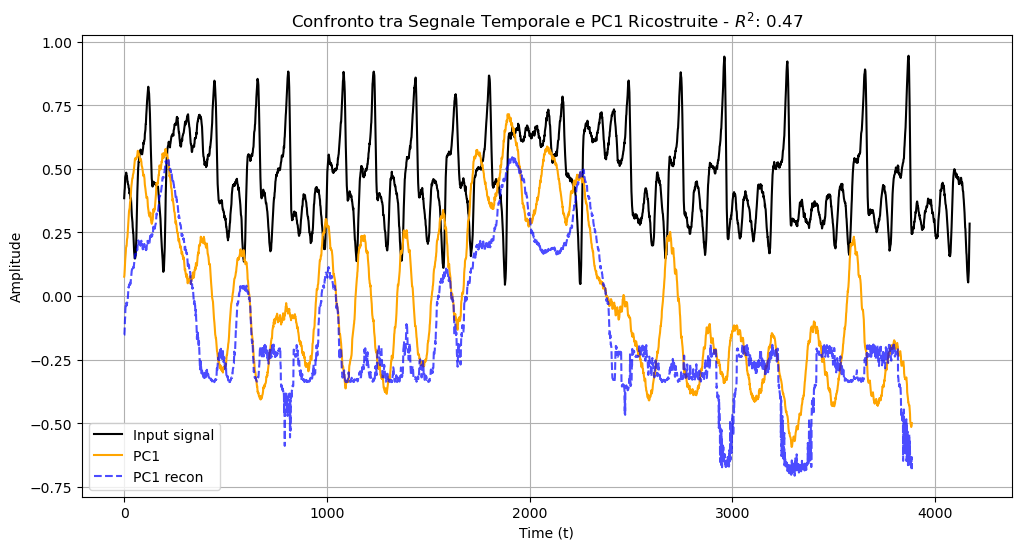

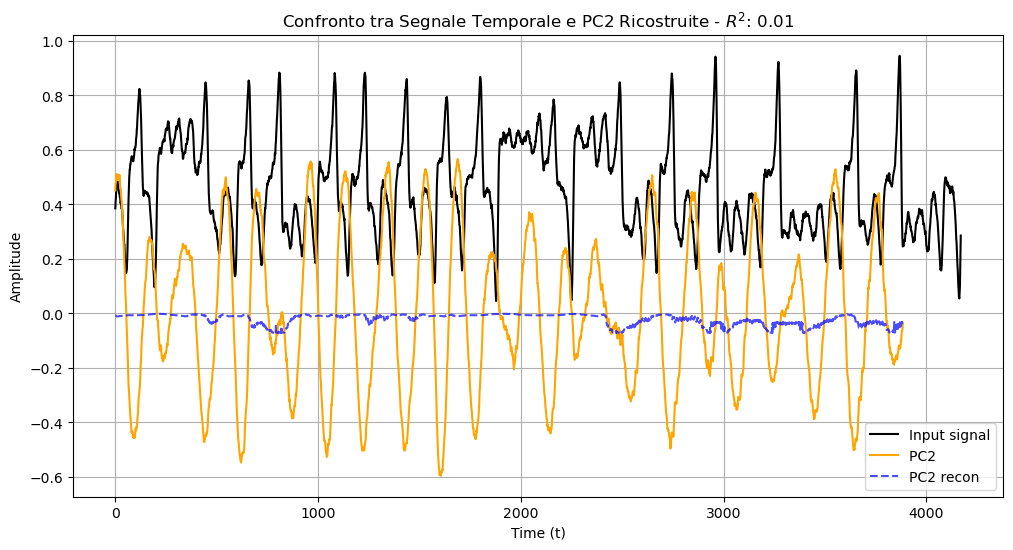

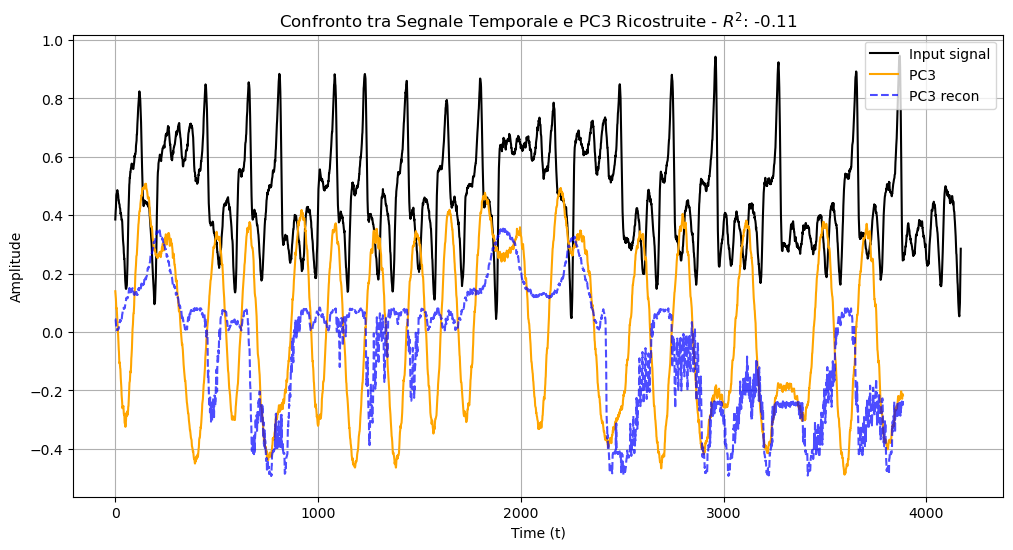

In [22]:
plot_temporal_signal_and_pcs(val_Z2, inputs, reconstructed_y2_1, n_components=3)

#### 2- Ricostruzione delle PC di $y_2(t)$ dagli embedding di $Z_2,Z_3$

In questo grafico analizziamo la capacità della rete di ricostruire le PC dei veri dati che la rete dovrebbe restituire.
Per le componenti di $y_2(t) = [Z_1,Z_3]^T + \beta \cdot \sigma$ costruiamo dai dati originali le matrici contenenti gli embedding. Poi uniamo le due matrici contenenti gli embedding delle variabili $[Z_1,Z_3]$ ottenendo una Matrice con shape (n_samples, 2* embedding dim ) in cui sono concatenati gli embedding delle due variabili e in seguito. Si usa poi su questi PCA.fit per calcolare media e varianza delle componenti principali e transform per ridurre la dimensionalità dei dati originali e plottare la componente principale come un segnale temporale.
Si applica poi la trasformazione sugli output della rete combinati allo stesso modo proiettandoli sulle componenti principali dei dati di reali.
Si calcola poi l'indice $R^2$ per analizzare la varianza tra la PC# ottenuta dai dati originali e la proiezione dei dati di output sulle stesse componenti.


In [23]:
def plot_pca_comparison_combined(original_signal, original_embeddings_z1, original_embeddings_z3, reconstructed_embeddings_z1, reconstructed_embeddings_z3, n_components=3):
    """
    Confronta il segnale temporale originale, le PC calcolate dagli embedding originali combinati,
    e le PC ricostruite combinando gli embedding di output della rete per \( Z1 \) e \( Z3 \).
    
    Parameters:
        original_signal (np.ndarray): Segnale temporale originale (1D array).
        original_embeddings_z1 (np.ndarray): Embedding originale di \( Z1 \) (2D array).
        original_embeddings_z3 (np.ndarray): Embedding originale di \( Z3 \) (2D array).
        reconstructed_embeddings_z1 (np.ndarray): Embedding ricostruito dalla rete per \( Z1 \) (2D array).
        reconstructed_embeddings_z3 (np.ndarray): Embedding ricostruito dalla rete per \( Z3 \) (2D array).
        n_components (int): Numero di componenti principali da calcolare.
    """
    # Combina gli embedding originali di Z1 e Z3
    original_embeddings_combined = np.hstack([original_embeddings_z1, original_embeddings_z3])
    # Combina gli embedding ricostruiti di Z1 e Z3
    reconstructed_embeddings_combined = np.hstack([reconstructed_embeddings_z1, reconstructed_embeddings_z3])

    # PCA sugli embedding combinati originali
    pca = PCA(n_components=n_components)
    pc_original = pca.fit_transform(original_embeddings_combined)  # Tutte le PC dagli embedding originali combinati
    pc_reconstructed = pca.transform(reconstructed_embeddings_combined)  # Proiezione delle PC combinate ricostruite

    # Plot per ogni componente principale
    for i in range(n_components):
        # Calcola R^2 tra la PC originale e quella ricostruita
        r2 = r2_score(pc_original[:, i], pc_reconstructed[:, i])

        # Plot
        plt.figure(figsize=(12, 6))
        plt.plot(original_signal, label='Input signal', color='black', lw=1.5)
        plt.plot(pc_original[:, i], label=f'PC{i+1}', color='orange', lw=1.5)
        plt.plot(pc_reconstructed[:, i], label=f'PC{i+1} recon', linestyle='--', color='blue', alpha=0.7, lw=1.5)
        plt.title(f"Confronto tra Segnale Temporale e PC{i+1} Ricostruite (Z1+Z3) - $R^2$: {r2:.2f}")
        plt.xlabel("Time (t)")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
        plt.show()


<>:2: SyntaxWarning: invalid escape sequence '\('
<>:2: SyntaxWarning: invalid escape sequence '\('
C:\Users\Federico\AppData\Local\Temp\ipykernel_12740\2255110318.py:2: SyntaxWarning: invalid escape sequence '\('
  """


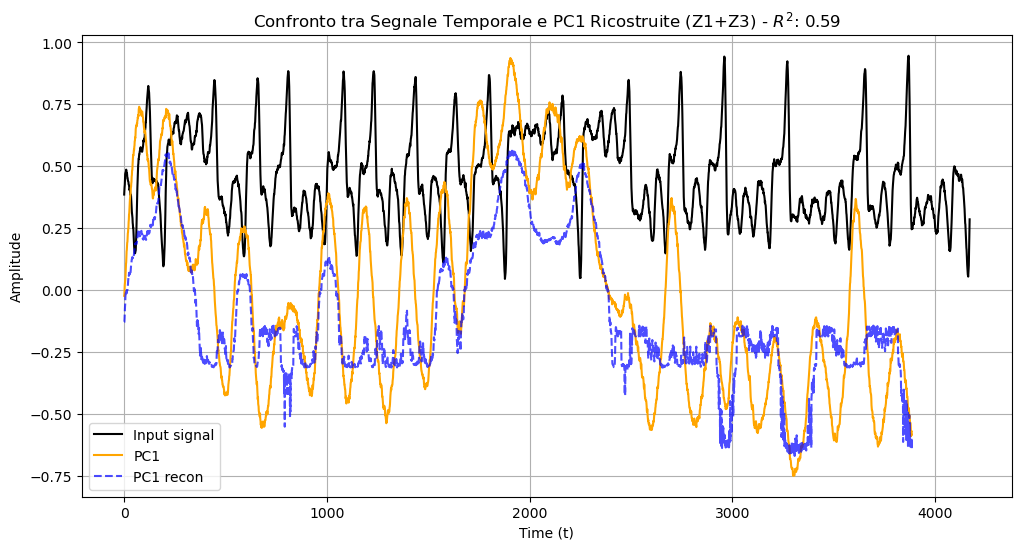

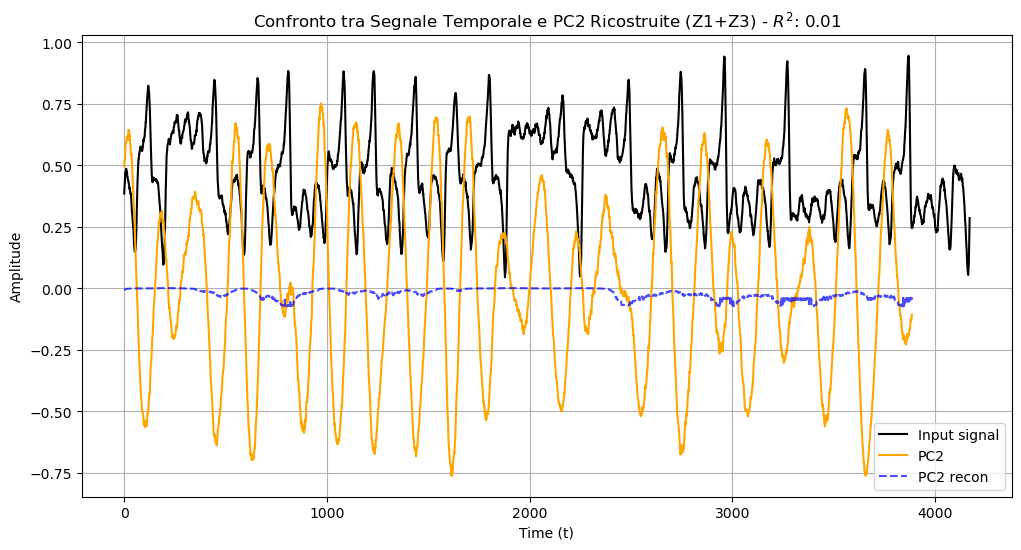

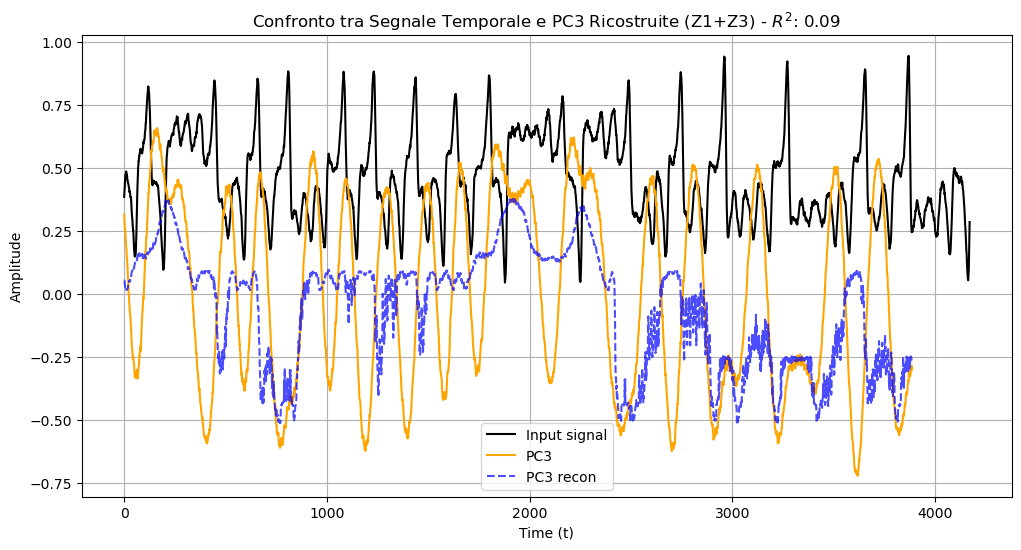

In [24]:
plot_pca_comparison_combined(val_Z2, original_y2_1, original_y2_2, reconstructed_y2_1, reconstructed_y2_2, n_components=3)

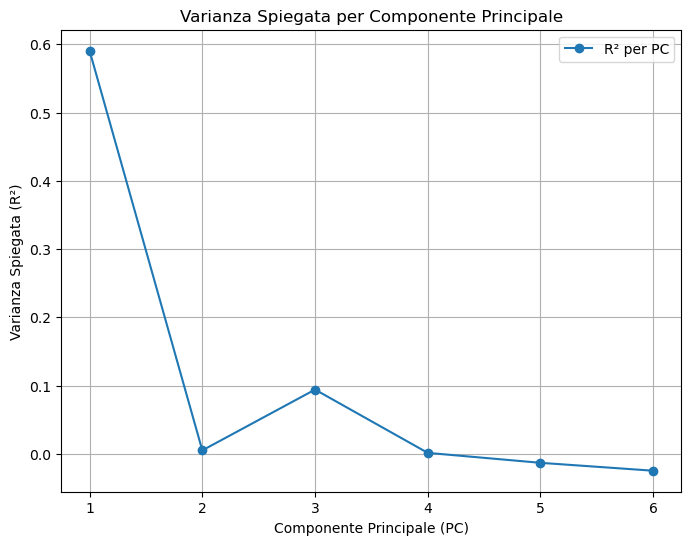

In [25]:
# Combina gli embedding originali di Z1 e Z3
original_embeddings_combined = np.hstack([original_y2_1, original_y2_2])
# Combina gli embedding ricostruiti di Z1 e Z3
reconstructed_embeddings_combined = np.hstack([reconstructed_y2_1, reconstructed_y2_2])

r2_Z1Z3 = pca_r2_analysis_embeddings(original_embeddings_combined, reconstructed_embeddings_combined, n_components=6)

In [26]:
output_path = "Analysis Data"
output_path += f"/{model_name}"
output_path += ".csv"

print (output_path)

save_analysis_data(model_name, 
                   latent_dim = selected_model_config["latent_dim"], 
                   r2_mean1 = mean_r21, r2_std1 = std_r21, 
                   mse_mean1 = mean_mse, mse_std1 = std_mse, 
                   maxse_mean1 = mean_max_se, maxse_std1 = std_max_se,
                   r2_mean2 = mean_r22, r2_std2 = std_r22,
                   mse_mean2 = mean_mse2, mse_std2 = std_mse2,
                   maxse_mean2 = mean_max_se2, maxse_std2 = std_max_se2,
                   r2_z1 = r2_z1, r2_z2 = r2_z2,r2_Z1Z3 = r2_Z1Z3,
                   r2_t_Z1=r2_1, r2_t_Z3=r2_2,
                   file_path=output_path)

Analysis Data/Prima prova.csv
Analysis data saved to Analysis Data/Prima prova.csv
